# Stock Price Prediction using LSTM model
## LSTM-based deep learning model to predict stock prices
### The model is trained on historical Google stock price data using a sliding window approach

### Import Required Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential, load_model
from keras.layers import LSTM, Dense, Dropout
from keras.initializers import Orthogonal
import joblib

### Load or Train the LSTM Model

In [2]:
def load_model_and_scaler():
    model_file = "trained_model.h5"
    scaler_file = "scaler.pkl"

    if os.path.isfile(model_file) and os.path.isfile(scaler_file):
        model = load_model(model_file)
        sc = joblib.load(scaler_file)
    else:
        model, sc = train_model()
        model.save(model_file)
        joblib.dump(sc, scaler_file)

    return model, sc


### Train Model Function

In [3]:
def train_model():
    data = pd.read_csv('Google_train_data.csv')
    data["Close"] = pd.to_numeric(data["Close"], errors='coerce')
    data = data.dropna()

    sc = MinMaxScaler(feature_range=(0, 1))
    closing_prices = data.iloc[:, 4:5].values
    closing_prices_scaled = sc.fit_transform(closing_prices)

    X_train, y_train = [], []
    for i in range(60, len(closing_prices_scaled)):
        X_train.append(closing_prices_scaled[i-60:i, 0])
        y_train.append(closing_prices_scaled[i, 0])

    X_train, y_train = np.array(X_train), np.array(y_train)
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

    model = Sequential()
    model.add(LSTM(100, return_sequences=True, input_shape=(X_train.shape[1], 1), kernel_initializer=Orthogonal()))
    model.add(Dropout(0.2))
    model.add(LSTM(100, return_sequences=True, kernel_initializer=Orthogonal()))
    model.add(Dropout(0.2))
    model.add(LSTM(100, return_sequences=True, kernel_initializer=Orthogonal()))
    model.add(Dropout(0.2))
    model.add(LSTM(100, return_sequences=False, kernel_initializer=Orthogonal()))
    model.add(Dropout(0.2))
    model.add(Dense(1, kernel_initializer=Orthogonal()))

    model.compile(optimizer='adam', loss="mean_squared_error")
    hist = model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=2)

    plt.figure(figsize=(8, 5))
    plt.plot(hist.history['loss'])
    plt.title('Training Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()

    return model, sc


### Predict Stock Prices

In [4]:
def predict_stock_price(model, sc, input_data):
    input_data_scaled = sc.transform(input_data)
    X_test = []

    for i in range(60, len(input_data_scaled)):
        X_test.append(input_data_scaled[i-60:i, 0])

    X_test = np.array(X_test)
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

    y_pred_scaled = model.predict(X_test)
    predicted_price = sc.inverse_transform(y_pred_scaled)

    return input_data[60:, 0], predicted_price.flatten()


### Save and Load Predicted Result

In [5]:
def save_test_results(actual_prices, predicted_prices):
    joblib.dump({"actual_prices": actual_prices, "predicted_prices": predicted_prices}, "test_results.pkl")

def load_test_results():
    if os.path.isfile("test_results.pkl"):
        data = joblib.load("test_results.pkl")
        return data["actual_prices"], data["predicted_prices"]
    else:
        return None, None


### Load Test Data

In [6]:
test_data = pd.read_csv('Google_test_data.csv')
test_data["Close"] = pd.to_numeric(test_data["Close"], errors='coerce')
test_data = test_data.dropna()
input_closing = test_data.iloc[:, 4:5].values


### Make Predictions

In [7]:
model, sc = load_model_and_scaler()
actual_prices, predicted_prices = predict_stock_price(model, sc, input_closing)

save_test_results(actual_prices, predicted_prices)


6/6 [==============================] - 2s 60ms/step


### Actual vs Predicted Stock Prices

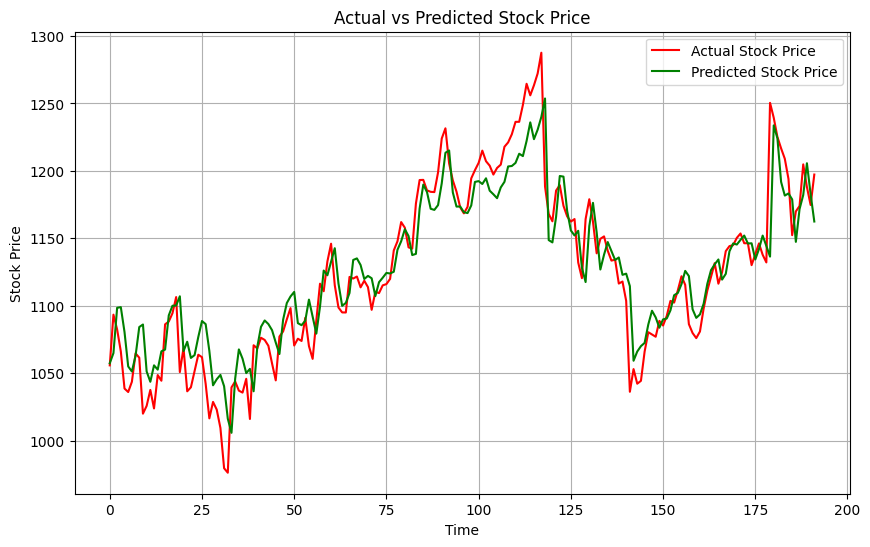

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(actual_prices, label='Actual Stock Price', color='red')
plt.plot(predicted_prices, label='Predicted Stock Price', color='green')
plt.title('Actual vs Predicted Stock Price')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()


### Visualize Train and Test Data

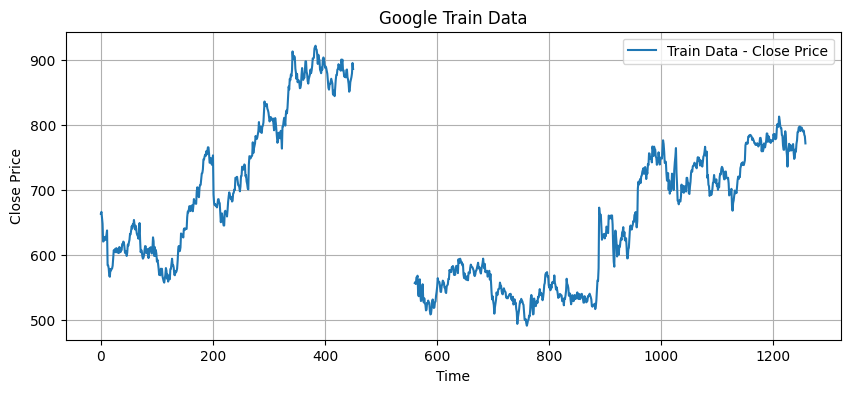

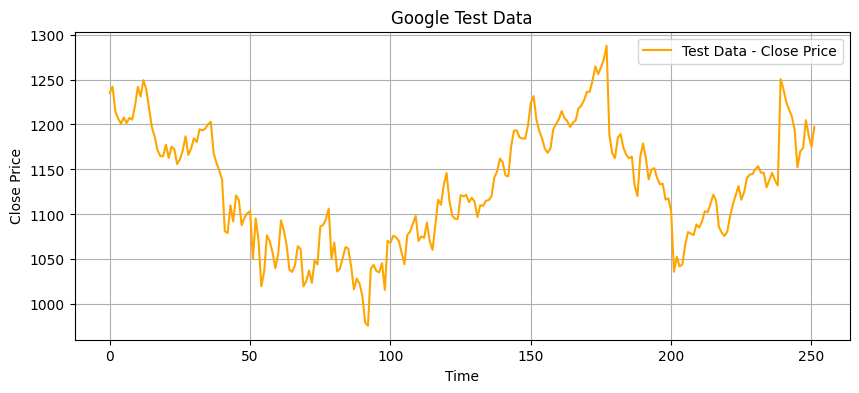

In [9]:
# Train data
train_data = pd.read_csv('Google_train_data.csv')
train_data["Close"] = pd.to_numeric(train_data["Close"], errors='coerce')

plt.figure(figsize=(10, 4))
plt.plot(train_data["Close"], label="Train Data - Close Price")
plt.title("Google Train Data")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.grid(True)
plt.legend()
plt.show()

# Test data
plt.figure(figsize=(10, 4))
plt.plot(test_data["Close"], label="Test Data - Close Price", color='orange')
plt.title("Google Test Data")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.grid(True)
plt.legend()
plt.show()
